In [2]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image   # python imaging library
import zipfile

In [3]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/img_align_celeba.zip"
EXTRACT_PATH = "/content/celeba"

if not os.path.exists(EXTRACT_PATH):
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

print("Extraction done")

CHECKPOINT_PATH = "/content/drive/MyDrive/GAN/checkpoint.pth"
OUTPUT_DIR = "/content/drive/MyDrive/GAN/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive
Extraction done


In [4]:
!ls /content/celeba

img_align_celeba


In [5]:
# image load => transform => dataset of all imgs
class ImageProcessor:
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

In [6]:
root_dir_path = "/content/celeba/img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178),   # 178 * 218 => 178 * 178
    transforms.Resize(64),    # 64 * 64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # (-1, 1)
])

In [7]:
dataset = ImageProcessor(root_dir_path, transformations)
# from torch.utils.data import Subset
# dataset = Subset(dataset, list(range(20000)))
print(f"Loaded {len(dataset)} data")



Loaded 202599 data


In [8]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Generator Network

In [9]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [10]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256 # upsampling
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels),
            nn.Tanh() # [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64)
        return img

        # fake img => 64 x 64 x 3 x batch_size

## Discriminator Network

In [11]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D

            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid() # probability of being real/fake
        )

    def forward(self, img):
        return self.model(img)

In [12]:
# g-loss => -log(D(G(z)))   -- minimize this ---- 0 very good, inf very bad

GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [13]:
import torch
# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is cuda


In [14]:
generator = generator.to(device)
discriminator = discriminator.to(device)

In [15]:
## Training the GAN

In [16]:
def train(generator, discriminator, dataloader, epochs=10):
    start_epoch = 0

    if os.path.exists(CHECKPOINT_PATH):
      start_epoch = load_checkpoint(generator, discriminator, g_optimizer, d_optimizer)
      print(f"Resuming from epoch {start_epoch+1}")

    for epoch in range(start_epoch, epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0....]

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device))

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}.... D-loss: {d_loss}")

            if i > 0 and i % 200 == 0:
                save_checkpoint(generator, discriminator, g_optimizer, d_optimizer, epoch)

        # save generated imgs for each epoch
        save_generated_images(generator, epoch, device)
        save_checkpoint(generator, discriminator, g_optimizer, d_optimizer, epoch)

In [17]:
def save_checkpoint(generator, discriminator, g_optimizer, d_optimizer, epoch):
    torch.save({
        "epoch": epoch,
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "g_optimizer_state_dict": g_optimizer.state_dict(),
        "d_optimizer_state_dict": d_optimizer.state_dict()
    }, CHECKPOINT_PATH)

def load_checkpoint(generator, discriminator, g_optimizer, d_optimizer):
    checkpoint = torch.load(CHECKPOINT_PATH)

    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    g_optimizer.load_state_dict(checkpoint["g_optimizer_state_dict"])
    d_optimizer.load_state_dict(checkpoint["d_optimizer_state_dict"])

    return checkpoint["epoch"]


In [18]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    generated_imgs = (generated_imgs + 1) / 2
    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

    plt.savefig(f"{OUTPUT_DIR}/epoch_{epoch+1}.png")
    plt.close()

Resuming from epoch 18
for epoch: 18/20... batch: 1... G-loss:1.4000775814056396.... D-loss: 0.5150120854377747
for epoch: 18/20... batch: 51... G-loss:1.3406084775924683.... D-loss: 0.5622079372406006
for epoch: 18/20... batch: 101... G-loss:1.186816930770874.... D-loss: 0.5447869300842285
for epoch: 18/20... batch: 151... G-loss:1.3292887210845947.... D-loss: 0.5825225114822388
for epoch: 18/20... batch: 201... G-loss:1.3621416091918945.... D-loss: 0.6166022419929504
for epoch: 18/20... batch: 251... G-loss:1.270056128501892.... D-loss: 0.5793880820274353
for epoch: 18/20... batch: 301... G-loss:1.3671693801879883.... D-loss: 0.5687894225120544
for epoch: 18/20... batch: 351... G-loss:1.279608964920044.... D-loss: 0.5165600180625916
for epoch: 18/20... batch: 401... G-loss:1.2526569366455078.... D-loss: 0.558036744594574
for epoch: 18/20... batch: 451... G-loss:1.3949743509292603.... D-loss: 0.5152320861816406
for epoch: 18/20... batch: 501... G-loss:1.4098424911499023.... D-loss: 0.

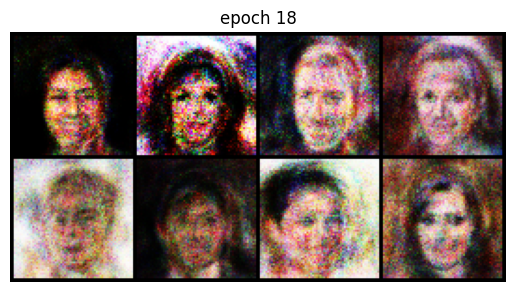

for epoch: 19/20... batch: 1... G-loss:1.1733245849609375.... D-loss: 0.5701076984405518
for epoch: 19/20... batch: 51... G-loss:1.312696933746338.... D-loss: 0.5157111883163452
for epoch: 19/20... batch: 101... G-loss:1.403240442276001.... D-loss: 0.5699401497840881
for epoch: 19/20... batch: 151... G-loss:1.3521478176116943.... D-loss: 0.5632377862930298
for epoch: 19/20... batch: 201... G-loss:1.3104584217071533.... D-loss: 0.5337731838226318
for epoch: 19/20... batch: 251... G-loss:1.3310433626174927.... D-loss: 0.5736874938011169
for epoch: 19/20... batch: 301... G-loss:1.4109983444213867.... D-loss: 0.556073784828186
for epoch: 19/20... batch: 351... G-loss:1.2610983848571777.... D-loss: 0.6022998094558716
for epoch: 19/20... batch: 401... G-loss:1.273848056793213.... D-loss: 0.5438264608383179
for epoch: 19/20... batch: 451... G-loss:1.3657221794128418.... D-loss: 0.6445515751838684
for epoch: 19/20... batch: 501... G-loss:1.421424150466919.... D-loss: 0.5514572858810425
for epo

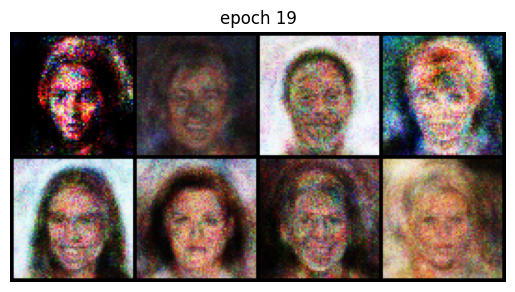

for epoch: 20/20... batch: 1... G-loss:1.3680870532989502.... D-loss: 0.5403995513916016
for epoch: 20/20... batch: 51... G-loss:1.3530035018920898.... D-loss: 0.5449079275131226
for epoch: 20/20... batch: 101... G-loss:1.3447325229644775.... D-loss: 0.615608274936676
for epoch: 20/20... batch: 151... G-loss:1.4749424457550049.... D-loss: 0.5664126873016357
for epoch: 20/20... batch: 201... G-loss:1.4039912223815918.... D-loss: 0.6115559339523315
for epoch: 20/20... batch: 251... G-loss:1.2526440620422363.... D-loss: 0.5998470783233643
for epoch: 20/20... batch: 301... G-loss:1.4412446022033691.... D-loss: 0.5574064254760742
for epoch: 20/20... batch: 351... G-loss:1.439124584197998.... D-loss: 0.5204702019691467
for epoch: 20/20... batch: 401... G-loss:1.3157528638839722.... D-loss: 0.5100729465484619
for epoch: 20/20... batch: 451... G-loss:1.346708059310913.... D-loss: 0.5830785036087036
for epoch: 20/20... batch: 501... G-loss:1.4059112071990967.... D-loss: 0.5199670791625977
for e

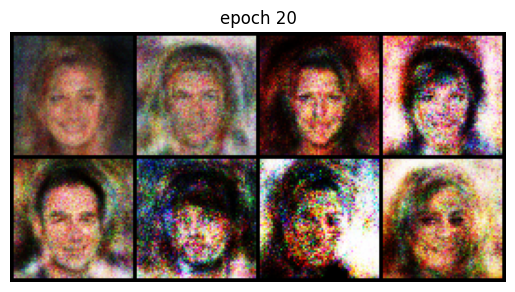

In [19]:
train(generator, discriminator, dataloader, epochs=20)